In [ ]:
## Этап 1. Импорт и анализ таблиц
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import math

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/My Drive/Colab Notebooks/CSV_and_Excel/Диплом/Новый диплом датасет update.xlsx'

df_orders = pd.read_excel(path,sheet_name ='Данные')
df_clients = pd.read_excel(path, sheet_name ='Clients')
df_regions = pd.read_excel(path, sheet_name ='Region_dict')

print(df_orders.head(10))

   id_order  id_client  amt_payment               dtime_pay
0    100238   194569.0       5373.0 2022-07-17 21:48:15.896
1    100242   191056.0       4151.0 2022-07-07 03:09:39.699
2    100249   200049.0       5688.0 2022-07-29 13:25:59.976
3    100258   206161.0       4330.0 2022-08-15 22:55:02.538
4    100267   190945.0       5488.0 2022-07-05 19:46:47.174
5    100271   183519.0       3727.0 2022-06-16 08:30:16.730
6    100276   189155.0       3580.0 2022-07-06 08:48:11.010
7    100282   205238.0       2861.0 2022-08-09 14:16:16.330
8    100285   195780.0          NaN                     NaT
9    100290   194417.0       2949.0 2022-07-14 11:46:51.767


In [ ]:
print(df_clients.head(10))

   id_client                dtime_ad  nflag_test  id_trading_point
0     180844 2022-06-08 18:38:41.414           0               212
1     193942                     NaT           0                13
2     226069 2022-07-11 16:28:38.511           1                54
3     183981 2022-06-16 12:23:59.289           1               991
4     322530 2022-07-08 08:56:08.714           0              1015
5     254313 2022-06-19 22:18:01.770           1               453
6     195818 2022-07-16 01:30:59.088           1              2652
7     267165 2022-06-25 09:54:06.470           0               866
8     246645 2022-07-03 22:13:08.299           0              1099
9     274394 2022-06-25 00:46:07.492           1              2652


In [ ]:
print(df_regions.head(10))

   id_trading_point              city
0                 1      Петрозаводск
1                 2           Дмитров
2                 4             Чехов
3                 7    Ростов Великий
4                11          Владимир
5                13   Нижний Новгород
6                19            Тюмень
7                23  Великий Новгород
8                26    Ростов-на-Дону
9                33            Самара


In [ ]:
# Проверка пропусков
print("Пропуски в заказах:\n", df_orders.isnull().sum())
print("\nПропуски в клиентах:\n", df_clients.isnull().sum())
print("\nПропуски в регионах:\n", df_regions.isnull().sum())

Пропуски в заказах:
 id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64

Пропуски в клиентах:
 id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
dtype: int64

Пропуски в регионах:
 id_trading_point    0
city                0
dtype: int64


In [ ]:
# Очистка: удаляем строки, где есть хотя бы одно пустое значение
df_orders = df_orders.dropna()
df_clients = df_clients.dropna()
df_regions = df_regions.dropna()

print("\nДанные очищены. Текущий размер таблиц:", df_orders.shape, df_clients.shape, df_regions.shape)


Данные очищены. Текущий размер таблиц: (35560, 4) (55356, 4) (66, 2)


In [ ]:
# Проверка пропусков итоговая
print("Пропуски в заказах:\n", df_orders.isnull().sum())
print("\nПропуски в клиентах:\n", df_clients.isnull().sum())
print("\nПропуски в регионах:\n", df_regions.isnull().sum())

Пропуски в заказах:
 id_order       0
id_client      0
amt_payment    0
dtime_pay      0
dtype: int64

Пропуски в клиентах:
 id_client           0
dtime_ad            0
nflag_test          0
id_trading_point    0
dtype: int64

Пропуски в регионах:
 id_trading_point    0
city                0
dtype: int64


/tmp/ipykernel_12613/3848036533.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_stats, x='city', y='id_trading_point', palette='viridis')


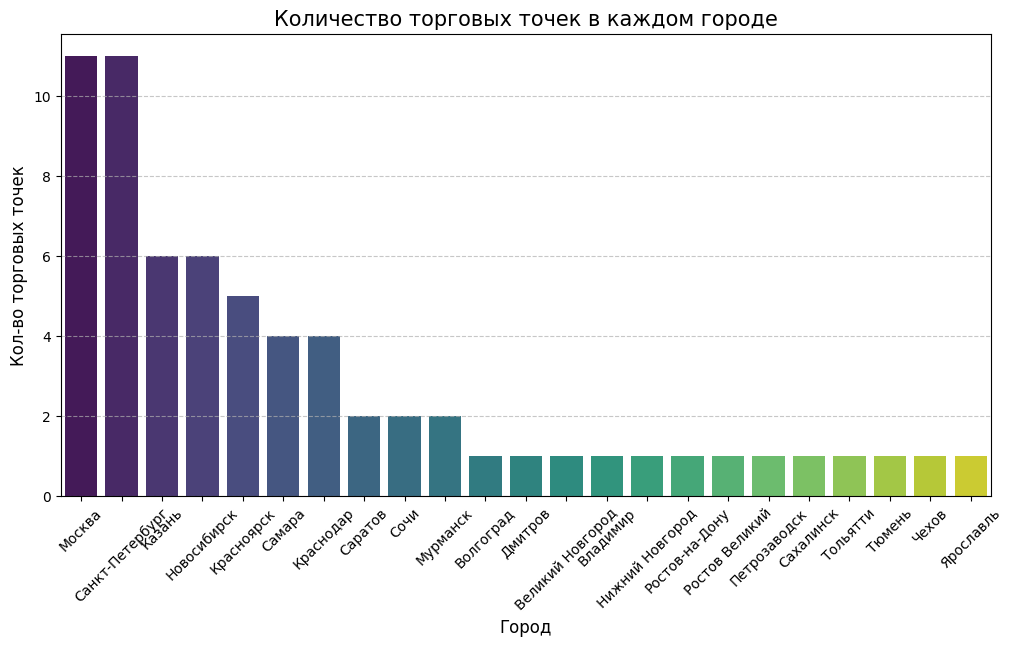

In [ ]:
# Группировка количества точек по городам
city_stats = df_regions.groupby('city')['id_trading_point'].count().sort_values(ascending=False).reset_index()

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(data=city_stats, x='city', y='id_trading_point', palette='viridis')

plt.title('Количество торговых точек в каждом городе', fontsize=15)
plt.xlabel('Город', fontsize=12)
plt.ylabel('Кол-во торговых точек', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
## Этап 2. Объединение таблиц
## 1. Агрегируем платежи по каждому клиенту
df_payments_agg = df_orders.groupby('id_client')['amt_payment'].sum().reset_index()

# 2. Соединяем таблицу клиентов с агрегированными платежами
# Используем left join, чтобы сохранить всех клиентов, даже тех, кто ничего не купил
df_merged = pd.merge(df_clients, df_payments_agg, on='id_client', how='left')

# 3. Заполняем нулями суммы покупок тех, кто не совершал транзакций
df_merged['amt_payment'] = df_merged['amt_payment'].fillna(0)

# 4. Подтягиваем города из словаря регионов
df_merged = pd.merge(df_merged, df_regions, on='id_trading_point', how='left')

# 5. Создаем флаг платежа (1 - купил, 0 - не купил)
df_merged['nflag_payment'] = df_merged['amt_payment'].apply(lambda x: 1 if x > 0 else 0)

# Проверим результат
print(df_merged.head())
print(f"\nВсего клиентов после объединения: {len(df_merged)}")

   id_client                dtime_ad  nflag_test  id_trading_point  \
0     180844 2022-06-08 18:38:41.414           0               212   
1     226069 2022-07-11 16:28:38.511           1                54   
2     183981 2022-06-16 12:23:59.289           1               991   
3     322530 2022-07-08 08:56:08.714           0              1015   
4     254313 2022-06-19 22:18:01.770           1               453   

   amt_payment             city  nflag_payment  
0       5349.0       Красноярск              1  
1          0.0         Мурманск              0  
2       6322.0           Казань              1  
3          0.0        Краснодар              0  
4          0.0  Санкт-Петербург              0  

Всего клиентов после объединения: 55356


In [ ]:
### Этап 3. Автоматизация статистических вычислений
# 1-2. Функция для T-теста (параметрический критерий)
def test_calc(r1, r2, alpha=0.05):
    """Вычисляет t-критерий Стьюдента для сравнения средних двух выборок."""
    t_stat, p_val = stats.ttest_ind(r1, r2)

    print(f"T-test: p-value = {p_val:.4f}")
    if p_val < alpha:
        print("Результат: Разница между средними СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)")
    else:
        print("Результат: Разница между средними СТАТИСТИЧЕСКИ НЕЗНАЧИМА (не удалось отвергнуть H0)")
    return t_stat, p_val

In [ ]:
# Генерируем случайные данные для теста (например, суммы покупок)
group_a = [100, 120, 110, 130, 140] # Контроль
group_b = [500, 600, 550, 580, 620] # Тест (явно больше)

print("=== Проверка функций на тестовых данных ===")
print("\n1. Проверка T-test:")
test_calc(group_a, group_b)

=== Проверка функций на тестовых данных ===

1. Проверка T-test:
T-test: p-value = 0.0000
Результат: Разница между средними СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)


(np.float64(-20.328927815368154), np.float64(3.583613355326253e-08))

In [ ]:
# 3-4. Функция для критерия Манна-Уитни (непараметрический критерий)
def mann_whitney_func(r1, r2, alpha=0.05):
    """Вычисляет критерий Манна-Уитни для сравнения распределений."""
    mw_stat, p_val = stats.mannwhitneyu(r1, r2, alternative='two-sided')

    print(f"Mann-Whitney: p-value = {p_val:.4f}")
    if p_val < alpha:
        print("Результат: Разница между распределениями СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)")
    else:
        print("Результат: Разница между распределениями СТАТИСТИЧЕСКИ НЕЗНАЧИМА (не удалось отвергнуть H0)")
    return mw_stat, p_val

In [ ]:
print("\n2. Проверка Mann-Whitney:")
mann_whitney_func(group_a, group_b)


2. Проверка Mann-Whitney:
Mann-Whitney: p-value = 0.0079
Результат: Разница между распределениями СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)


(np.float64(0.0), np.float64(0.007936507936507936))

In [ ]:
### Этап 4. Чистка неверно заполненных точек
# Список всех уникальных торговых точек
trading_points = df_merged['id_trading_point'].unique()

# 1. Точки с нулевыми платежами в одной из групп
points_zero_payment = []

for tp in trading_points:
    # Фильтруем данные по конкретной точке
    df_tp = df_merged[df_merged['id_trading_point'] == tp]

    # Считаем сумму платежей в контроле (0) и тесте (1)
    sum_control = df_tp[df_tp['nflag_test'] == 0]['amt_payment'].sum()
    sum_test = df_tp[df_tp['nflag_test'] == 1]['amt_payment'].sum()

    # Если в какой-то группе 0 рублей — добавляем в список
    if sum_control == 0 or sum_test == 0:
        points_zero_payment.append(tp)

print(f"Точки с нулевыми платежами: {points_zero_payment}")

Точки с нулевыми платежами: [np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(46), np.int64(228), np.int64(26), np.int64(603), np.int64(810), np.int64(800), np.int64(7), np.int64(23), np.int64(4), np.int64(1), np.int64(13)]


In [ ]:
# 2. Точки с "пустыми" группами (нет ни одного клиента)
points_empty_groups = []

for tp in trading_points:
    df_tp = df_merged[df_merged['id_trading_point'] == tp]

    # Считаем количество клиентов в каждой группе
    count_control = df_tp[df_tp['nflag_test'] == 0]['id_client'].count()
    count_test = df_tp[df_tp['nflag_test'] == 1]['id_client'].count()

    # Если одна из групп пуста — добавляем в список
    if count_control == 0 or count_test == 0:
        points_empty_groups.append(tp)

print(f"Точки с пустыми группами: {points_empty_groups}")

Точки с пустыми группами: [np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(228), np.int64(603), np.int64(810), np.int64(800)]


In [ ]:
# Объединяем списки точек для исключения (используем set для уникальности)
points_to_exclude = list(set(points_zero_payment + points_empty_groups))

# Создаем финальный чистый датасет
df_final = df_merged[~df_merged['id_trading_point'].isin(points_to_exclude)]

print(f"Исключено точек: {len(points_to_exclude)}")
print(f"Осталось клиентов для анализа: {len(df_final)}")

Исключено точек: 15
Осталось клиентов для анализа: 45318


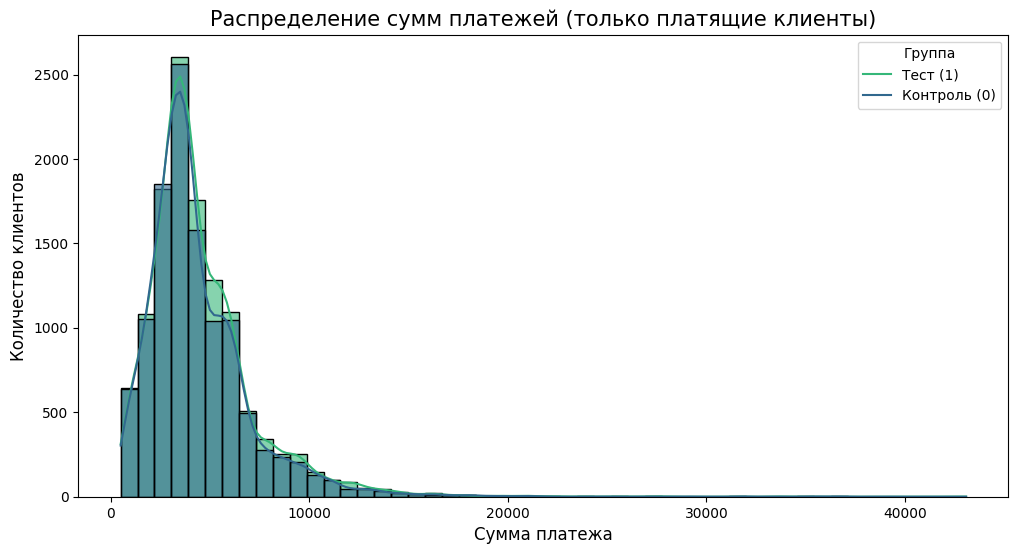

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_final[df_final['amt_payment'] > 0], x='amt_payment', hue='nflag_test',
             bins=50, kde=True, palette='viridis', alpha=0.6)

plt.title('Распределение сумм платежей (только платящие клиенты)', fontsize=15)
plt.xlabel('Сумма платежа', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend(title='Группа', labels=['Тест (1)', 'Контроль (0)'])
plt.show()

In [ ]:
## Этап 5. Расчет общих результатов A/B-теста
# Разделяем данные для удобства
control = df_final[df_final['nflag_test'] == 0]
test = df_final[df_final['nflag_test'] == 1]

print("=== РЕЗУЛЬТАТЫ ПО ВСЕЙ ВЫБОРКЕ ===")

# 3. Сравнение средних платежей (ARPU) через T-test
print("\n1. Сравнение средних платежей (ARPU):")
test_calc(control['amt_payment'], test['amt_payment'])

# 4. Сравнение Конверсии (CR) через T-test
# (Передаем колонку nflag_payment, где 1 - купил, 0 - нет)
print("\n2. Сравнение конверсии в платеж (CR):")
test_calc(control['nflag_payment'], test['nflag_payment'])

# 5. Сравнение распределений через Манна-Уитни
print("\n3. Сравнение распределений платежей (Mann-Whitney):")
mann_whitney_func(control['amt_payment'], test['amt_payment'])

=== РЕЗУЛЬТАТЫ ПО ВСЕЙ ВЫБОРКЕ ===

1. Сравнение средних платежей (ARPU):
T-test: p-value = 0.0000
Результат: Разница между средними СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)

2. Сравнение конверсии в платеж (CR):
T-test: p-value = 0.0000
Результат: Разница между средними СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)

3. Сравнение распределений платежей (Mann-Whitney):
Mann-Whitney: p-value = 0.0000
Результат: Разница между распределениями СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)


(np.float64(243344369.0), np.float64(3.008345273971901e-24))

In [ ]:
## Этап 6. Сегментация результатов A/B-теста
city_name = 'Москва'
df_moscow = df_final[df_final['city'] == city_name]

print(f"=== РЕЗУЛЬТАТЫ: {city_name.upper()} ===")
print(f"Количество участников: {len(df_moscow)}")

# Разделяем на группы
control_m = df_moscow[df_moscow['nflag_test'] == 0]
test_m = df_moscow[df_moscow['nflag_test'] == 1]

# Вызываем функции
print("\n1. Сравнение ARPU (T-test):")
test_calc(control_m['amt_payment'], test_m['amt_payment'])

print("\n2. Сравнение Конверсии (T-test):")
test_calc(control_m['nflag_payment'], test_m['nflag_payment'])

print("\n3. Сравнение распределений (Mann-Whitney):")
mann_whitney_func(control_m['amt_payment'], test_m['amt_payment'])

=== РЕЗУЛЬТАТЫ: МОСКВА ===
Количество участников: 12358

1. Сравнение ARPU (T-test):
T-test: p-value = 0.0000
Результат: Разница между средними СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)

2. Сравнение Конверсии (T-test):
T-test: p-value = 0.0000
Результат: Разница между средними СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)

3. Сравнение распределений (Mann-Whitney):
Mann-Whitney: p-value = 0.0000
Результат: Разница между распределениями СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)


(np.float64(17582441.5), np.float64(7.010591402203484e-16))

=== РЕЗУЛЬТАТЫ: МОСКВА ===
Количество участников: 12358


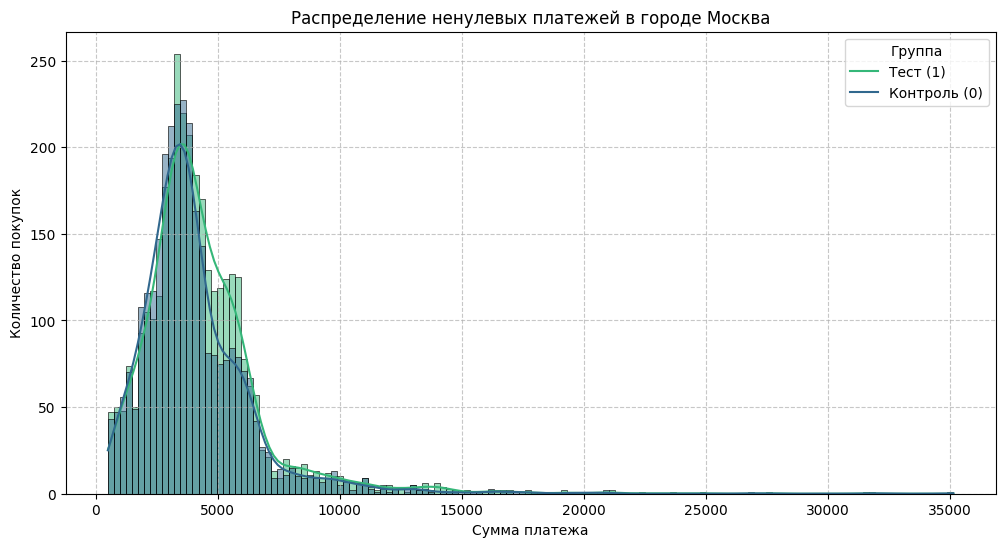


1. Сравнение ARPU (T-test):
T-test: p-value = 0.0000
Результат: Разница между средними СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)

2. Сравнение Конверсии (T-test):
T-test: p-value = 0.0000
Результат: Разница между средними СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)

3. Сравнение распределений (Mann-Whitney):
Mann-Whitney: p-value = 0.0000
Результат: Разница между распределениями СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)


(np.float64(17582441.5), np.float64(7.010591402203484e-16))

In [ ]:
## Этап 6. Сегментация результатов A/B-теста (Москва)
city_name = 'Москва'
df_moscow = df_final[df_final['city'] == city_name]

print(f"=== РЕЗУЛЬТАТЫ: {city_name.upper()} ===")
print(f"Количество участников: {len(df_moscow)}")

# 1. Визуализация распределения платежей по Москве
plt.figure(figsize=(12, 6))
sns.histplot(data=df_moscow[df_moscow['amt_payment'] > 0],
             x='amt_payment',
             hue='nflag_test',
             kde=True,
             palette='viridis',
             common_norm=False)

plt.title(f'Распределение ненулевых платежей в городе {city_name}')
plt.xlabel('Сумма платежа')
plt.ylabel('Количество покупок')
plt.legend(title='Группа', labels=['Тест (1)', 'Контроль (0)'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Разделяем на группы для расчетов
control_m = df_moscow[df_moscow['nflag_test'] == 0]
test_m = df_moscow[df_moscow['nflag_test'] == 1]

# 3. Вызываем функции анализа
print("\n1. Сравнение ARPU (T-test):")
test_calc(control_m['amt_payment'], test_m['amt_payment'])

print("\n2. Сравнение Конверсии (T-test):")
test_calc(control_m['nflag_payment'], test_m['nflag_payment'])

print("\n3. Сравнение распределений (Mann-Whitney):")
mann_whitney_func(control_m['amt_payment'], test_m['amt_payment'])

=== РЕЗУЛЬТАТЫ: САНКТ-ПЕТЕРБУРГ ===
Количество участников: 8879


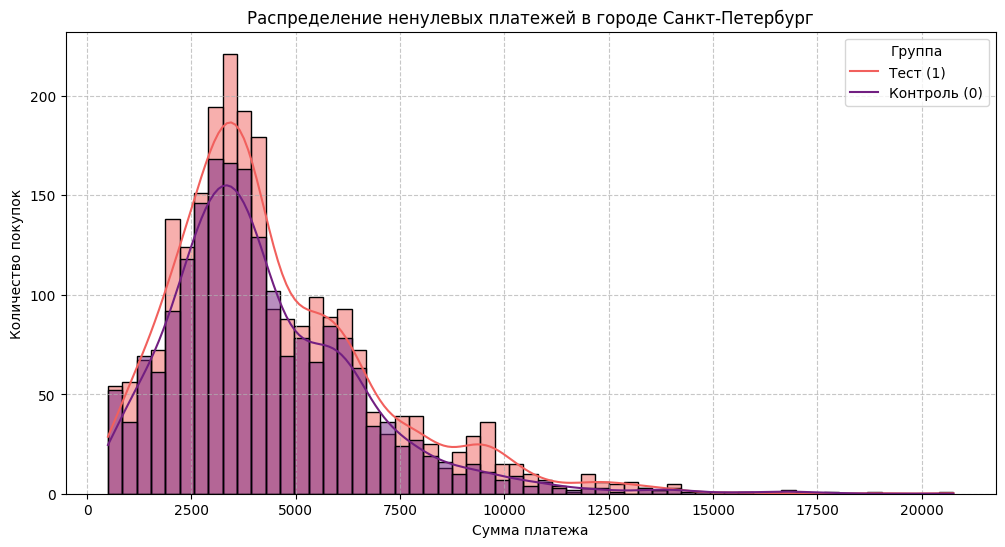


1. Сравнение ARPU (T-test):
T-test: p-value = 0.0000
Результат: Разница между средними СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)

2. Сравнение Конверсии (T-test):
T-test: p-value = 0.0000
Результат: Разница между средними СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)

3. Сравнение распределений (Mann-Whitney):
Mann-Whitney: p-value = 0.0000
Результат: Разница между распределениями СТАТИСТИЧЕСКИ ЗНАЧИМА (отвергаем H0)


(np.float64(8809444.5), np.float64(2.0392184217953754e-20))

In [ ]:
city_name = 'Санкт-Петербург'
df_spb = df_final[df_final['city'] == city_name]

print(f"=== РЕЗУЛЬТАТЫ: {city_name.upper()} ===")
print(f"Количество участников: {len(df_spb)}")

# 1. Визуализация распределения платежей по Санкт-Петербургу
plt.figure(figsize=(12, 6))
sns.histplot(data=df_spb[df_spb['amt_payment'] > 0],
             x='amt_payment',
             hue='nflag_test',
             kde=True,
             palette='magma',
             common_norm=False)

plt.title(f'Распределение ненулевых платежей в городе {city_name}')
plt.xlabel('Сумма платежа')
plt.ylabel('Количество покупок')
plt.legend(title='Группа', labels=['Тест (1)', 'Контроль (0)'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Разделяем на группы для расчетов
control_s = df_spb[df_spb['nflag_test'] == 0]
test_s = df_spb[df_spb['nflag_test'] == 1]

# 3. Вызываем функции анализа
print("\n1. Сравнение ARPU (T-test):")
test_calc(control_s['amt_payment'], test_s['amt_payment'])

print("\n2. Сравнение Конверсии (T-test):")
test_calc(control_s['nflag_payment'], test_s['nflag_payment'])

print("\n3. Сравнение распределений (Mann-Whitney):")
mann_whitney_func(control_s['amt_payment'], test_s['amt_payment'])


РЕЗУЛЬТАТЫ: КРАСНОЯРСК
Количество участников: 5937
- ARPU:
T-test: p-value = 0.9045
Результат: Разница между средними СТАТИСТИЧЕСКИ НЕЗНАЧИМА (не удалось отвергнуть H0)
- Конверсия:
T-test: p-value = 0.7805
Результат: Разница между средними СТАТИСТИЧЕСКИ НЕЗНАЧИМА (не удалось отвергнуть H0)

РЕЗУЛЬТАТЫ: МУРМАНСК
Количество участников: 2120
- ARPU:
T-test: p-value = 0.9450
Результат: Разница между средними СТАТИСТИЧЕСКИ НЕЗНАЧИМА (не удалось отвергнуть H0)
- Конверсия:
T-test: p-value = 0.3976
Результат: Разница между средними СТАТИСТИЧЕСКИ НЕЗНАЧИМА (не удалось отвергнуть H0)

РЕЗУЛЬТАТЫ: КАЗАНЬ
Количество участников: 5077
- ARPU:
T-test: p-value = 0.2867
Результат: Разница между средними СТАТИСТИЧЕСКИ НЕЗНАЧИМА (не удалось отвергнуть H0)
- Конверсия:
T-test: p-value = 0.7848
Результат: Разница между средними СТАТИСТИЧЕСКИ НЕЗНАЧИМА (не удалось отвергнуть H0)

РЕЗУЛЬТАТЫ: САРАТОВ
Количество участников: 2122
- ARPU:
T-test: p-value = 0.9163
Результат: Разница между средними СТАТИСТИЧЕС

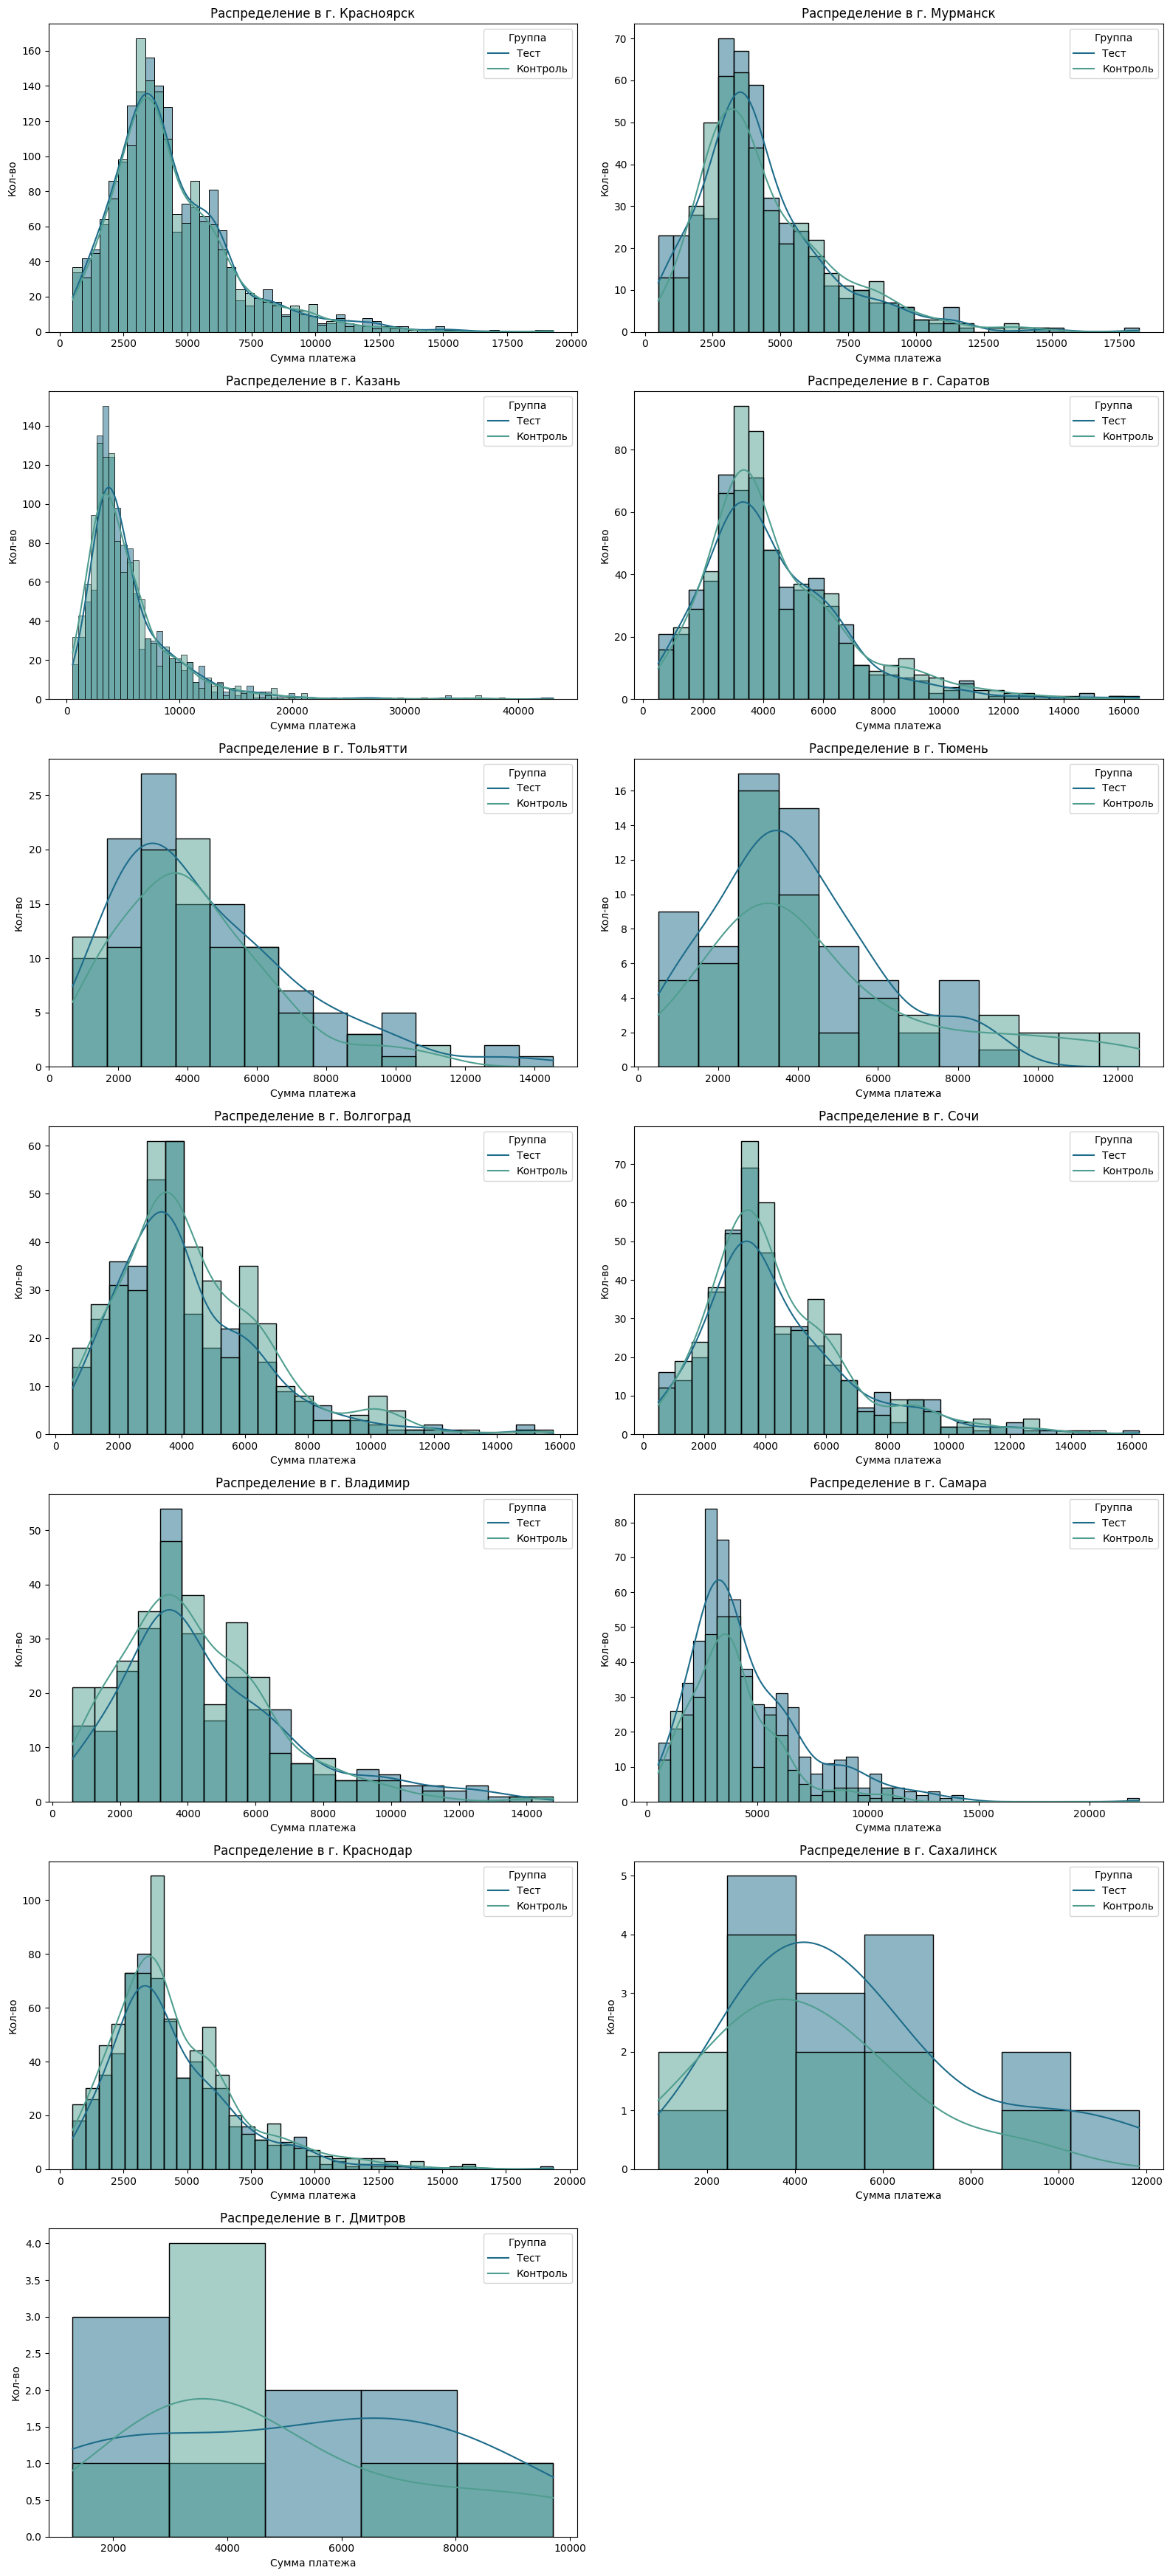

In [ ]:
# Список всех городов, кроме уже проанализированных
other_cities = [c for c in df_final['city'].unique() if c not in ['Москва', 'Санкт-Петербург']]

# Рассчитываем размер сетки (например, по 2 графика в ряд)
cols = 2
rows = math.ceil(len(other_cities) / cols)

# Создаем общее полотно
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten() # Превращаем матрицу осей в плоский список для удобства итерации

for i, city in enumerate(other_cities):
    df_city = df_final[df_final['city'] == city]
    ax = axes[i] # Выбираем текущую ячейку для графика

    # 1. Визуализация на конкретной оси (ax)
    sns.histplot(data=df_city[df_city['amt_payment'] > 0],
                 x='amt_payment',
                 hue='nflag_test',
                 kde=True,
                 ax=ax,
                 palette='crest',
                 common_norm=False)

    ax.set_title(f'Распределение в г. {city}')
    ax.set_xlabel('Сумма платежа')
    ax.set_ylabel('Кол-во')
    ax.legend(title='Группа', labels=['Тест', 'Контроль'])

    # 2. Статистический вывод в консоль
    print("\n" + "="*40)
    print(f"РЕЗУЛЬТАТЫ: {city.upper()}")
    print(f"Количество участников: {len(df_city)}")

    c_grp = df_city[df_city['nflag_test'] == 0]
    t_grp = df_city[df_city['nflag_test'] == 1]

    print("- ARPU:")
    test_calc(c_grp['amt_payment'], t_grp['amt_payment'])

    print("- Конверсия:")
    test_calc(c_grp['nflag_payment'], t_grp['nflag_payment'])

# Удаляем пустые ячейки, если городов нечетное количество
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Чтобы графики не наезжали друг на друга
plt.show()

In [ ]:
## Этап 7. Отчет по A/B-тесту

# 1. Создаем список для сбора данных (так быстрее, чем append в DataFrame)
results_list = []
total_n = len(df_final) # Общее кол-во наблюдений для расчета %

# Получаем список уникальных пар Город-Точка
tp_list = df_final[['city', 'id_trading_point']].drop_duplicates().values

for city, tp in tp_list:
    # Выборка данных по конкретной точке
    df_tp = df_final[df_final['id_trading_point'] == tp]

    # Группы
    control = df_tp[df_tp['nflag_test'] == 0]['amt_payment']
    test = df_tp[df_tp['nflag_test'] == 1]['amt_payment']

    # Расчет базовых метрик
    n_test = len(test)
    n_control = len(control)
    avg_test = test.mean()
    avg_control = control.mean()
    diff = avg_test - avg_control

    # Стандартное отклонение (Sigma)
    sigma_test = test.std()
    sigma_control = control.std()

    # T-test
    t_stat, p_val = stats.ttest_ind(test, control)

    # 3. Присвоение лейбла
    if p_val < 0.05 and diff > 0:
        label = 'Положительный исход'
    elif p_val < 0.05 and diff < 0:
        label = 'Отрицательный исход'
    else:
        label = 'Нейтральный исход'

    # Добавляем в список
    results_list.append({
        'city': city,
        'id_trading_point': tp,
        'count_test': n_test,
        'count_control': n_control,
        'count_all': n_test + n_control,
        'percent_count': (n_test + n_control) / total_n,
        'avg_payment_test': avg_test,
        'avg_payment_control': avg_control,
        'diff': diff,
        'sigma_test': sigma_test,
        'sigma_control': sigma_control,
        'ttest': t_stat,
        'pvalue_ttest': p_val,
        'label': label
    })

# Создаем итоговый DataFrame
df_report = pd.DataFrame(results_list)
print(df_report.head(10))

              city  id_trading_point  count_test  count_control  count_all  \
0       Красноярск               212         593            575       1168   
1         Мурманск                54         633            640       1273   
2           Казань               991         270            294        564   
3  Санкт-Петербург               453        1066           1049       2115   
4           Москва              2652        2273           2370       4643   
5       Красноярск               278         535            489       1024   
6           Москва              6543         662            689       1351   
7           Казань               699         482            494        976   
8           Казань               477         382            386        768   
9           Казань               544         377            416        793   

   percent_count  avg_payment_test  avg_payment_control        diff  \
0       0.025773       2144.317032          2222.052174  -77.735142   

In [ ]:
# Устанавливаем библиотеку (если её нет в окружении)
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 3.9 MB/s eta 0:00:00


In [ ]:
# Ваш путь (убедитесь, что Google Диск примонтирован)
save_path = '/content/drive/My Drive/Colab Notebooks/CSV_and_Excel/Диплом/ab_test_report.xlsx'

# 2. Сохраняем в Excel с разделением по листам
try:
    with pd.ExcelWriter(save_path, engine='xlsxwriter') as writer:
        # Цикл по уникальным лейблам для создания листов
        for label in df_report['label'].unique():
            # Фильтруем данные для текущего листа
            df_subset = df_report[df_report['label'] == label]

            # Очищаем название лейбла для корректного имени листа (макс 31 символ)
            sheet_name = str(label)[:31]

            # Записываем данные
            df_subset.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f"✅ Файл успешно сохранен по пути: {save_path}")
except Exception as e:
    print(f"❌ Ошибка при сохранении: {e}")
    print("Проверьте, примонтирован ли Google Диск командой drive.mount('/content/drive')")

✅ Файл успешно сохранен по пути: /content/drive/My Drive/Colab Notebooks/CSV_and_Excel/Диплом/ab_test_report.xlsx


In [ ]:
## ТЗ_Калькулятор

# 1. Путь к файлу
save_path = '/content/drive/My Drive/Colab Notebooks/CSV_and_Excel/Диплом/ab_test_calculator_final.xlsx'
# 1. Подготовка данных
df_pos = df_report[df_report['label'] == 'Положительный исход'].copy().fillna(0)
df_neg = df_report[df_report['label'] == 'Отрицательный исход'].copy().fillna(0)
df_neu = df_report[df_report['label'] == 'Нейтральный исход'].copy().fillna(0)

with pd.ExcelWriter(save_path, engine='xlsxwriter') as writer:
    workbook = writer.book

    # Стили
    yellow_fmt = workbook.add_format({'bg_color': '#FFFF00', 'border': 1, 'bold': True})
    header_fmt = workbook.add_format({'bold': True, 'border': 1, 'align': 'center', 'bg_color': '#F2F2F2'})
    val_fmt = workbook.add_format({'border': 1})
    money_fmt = workbook.add_format({'border': 1, 'num_format': '#,##0.00'})

    # --- ЛИСТ: ИТОГ ---
    ws_sum = workbook.add_worksheet('Итог')
    ws_sum.set_column('A:A', 40)
    ws_sum.set_column('B:B', 20)

    # Вводные данные
    ws_sum.write('A1', 'Параметр', yellow_fmt)
    ws_sum.write('B1', 'Значение', yellow_fmt)
    ws_sum.write('A2', 'N (количество клиентов на ТТ)')
    ws_sum.write('B2', 1000, val_fmt)
    ws_sum.write('A3', 'MDE (минимальный эффект, руб)')
    ws_sum.write('B3', 1000, val_fmt)

    # Расчетные поля (формулы суммируют столбцы P на соответствующих листах)
    ws_sum.write('A5', 'Прирост выручки (сумма по успешным ТТ)', yellow_fmt)
    ws_sum.write_formula('B5', "=SUM('Положительные исходы'!O:O)", money_fmt)

    ws_sum.write('A6', 'Падение выручки (сумма по неуспешным ТТ)', yellow_fmt)
    ws_sum.write_formula('B6', "=SUM('Отрицательные исходы'!O:O)", money_fmt)

    ws_sum.write('A7', 'Баланс', yellow_fmt)
    ws_sum.write_formula('B7', "=B5+B6", money_fmt)

    ws_sum.write('A8', 'Количество наблюдений (сумма по нейтральным ТТ)', yellow_fmt)
    ws_sum.write_formula('B8', "=SUM('Нейтральные исходы'!O:O)", val_fmt)

    # --- ФУНКЦИЯ ЗАПОЛНЕНИЯ ДАННЫХ ---
    def fill_data_sheet(df, sheet_name, mode):
        # Записываем таблицу с заголовками (начиная с 1-й строки Excel)
        df.to_excel(writer, sheet_name=sheet_name, index=False)
        ws = writer.sheets[sheet_name]

        # Добавляем заголовок для столбца P (индекс 14) в общую таблицу
        col_title = 'Прибыль/Убыток' if mode == 'revenue' else 'Требуемое N'
        ws.write(0, 14, col_title, header_fmt)
        ws.set_column('O:O', 20)

        # Пишем формулы в каждую строку столбца O
        for i in range(len(df)):
            row_excel = i + 2 # +2 т.к. в Excel отсчет с 1 и есть заголовок

            if mode == 'revenue':
                # Формула: diff(I) * N(Итог!B2) * доля(F)
                formula = f"=I{row_excel}*Итог!$B$2*F{row_excel}"
                ws.write_formula(i + 1, 14, formula, money_fmt)
            else:
                # Формула: 16 * sigma_control^2(K) / MDE^2(Итог!B3)
                formula = f"=IF(Итог!$B$3=0, 0, 16*(K{row_excel}^2)/(Итог!$B$3^2))"
                ws.write_formula(i + 1, 14, formula, val_fmt)

    # Заполнение
    fill_data_sheet(df_pos, 'Положительные исходы', 'revenue')
    fill_data_sheet(df_neg, 'Отрицательные исходы', 'revenue')
    fill_data_sheet(df_neu, 'Нейтральные исходы', 'neutral')

print(f"✅ Готово! Файл: {save_path}")

✅ Готово! Файл: /content/drive/My Drive/Colab Notebooks/CSV_and_Excel/Диплом/ab_test_calculator_final.xlsx
